<a href="https://colab.research.google.com/github/jainMaurya/UCS547-Accelerated-Data-Science/blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Q1: CPU vs GPU Image Pipeline**

In [7]:
import cv2
import time
import os

folder="/content/images/data"

img_list=[f for f in os.listdir(folder) if f.endswith((".jpg",".jpeg",".png"))]

start=time.time()

for name in img_list:

    path=os.path.join(folder,name)

    image=cv2.imread(path)

    resized=cv2.resize(image,(512,512))

    gray=cv2.cvtColor(resized,cv2.COLOR_BGR2GRAY)

cpu_time=time.time()-start

cpu_avg=cpu_time/len(img_list)

print("CPU Total:",cpu_time)

print("CPU Avg:",cpu_avg)

CPU Total: 9.083068609237671
CPU Avg: 0.5676917880773544


In [8]:
import time
from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

class PipeGPU(Pipeline):

    def __init__(self,batch_sz,threads,dev_id,data_path):

        super(PipeGPU,self).__init__(batch_sz,threads,dev_id)

        self.input=fn.readers.file(file_root=data_path)

    def define_graph(self):

        jpegs,labels=self.input

        decoded=fn.decoders.image(jpegs,device="mixed")

        resized=fn.resize(decoded,resize_x=512,resize_y=512)

        gray=fn.color_space_conversion(
            resized,
            image_type=types.RGB,
            output_type=types.GRAY
        )

        return gray

path="/content/images"

batch=4

gpu_pipe=PipeGPU(batch,2,0,path)

gpu_pipe.build()

start=time.time()

gpu_pipe.run()

gpu_time=time.time()-start

gpu_avg=gpu_time/15

speedup=cpu_time/gpu_time

print("GPU Total:",gpu_time)

print("GPU Avg:",gpu_avg)

print("Speedup:",speedup)

GPU Total: 2.2837910652160645
GPU Avg: 0.15225273768107098
Speedup: 3.977188958998901


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

results={
    "Metric":["Total Time","Average Time per Image","Speedup"],
    "CPU":[cpu_time,cpu_avg,"-"],
    "GPU":[gpu_time,gpu_avg,speedup]
}

df=pd.DataFrame(results)

print(df)

                   Metric       CPU       GPU
0              Total Time  9.083069  2.283791
1  Average Time per Image  0.567692  0.152253
2                 Speedup         -  3.977189


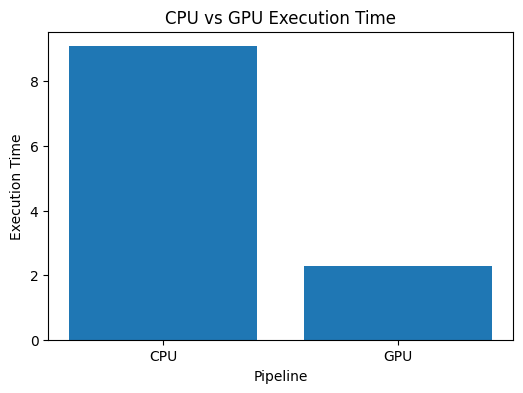

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["CPU","GPU"],
    [cpu_time,gpu_time]
)

plt.xlabel("Pipeline")

plt.ylabel("Execution Time")

plt.title("CPU vs GPU Execution Time")

plt.show()

# **Q2: Grayscale Conversion**

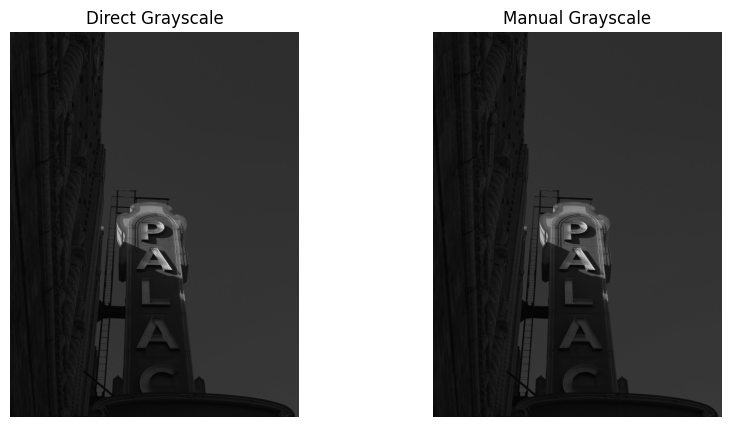

In [12]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn

class DecodeGPU(Pipeline):

    def __init__(self,batch_sz,threads,dev_id,data_path):

        super(DecodeGPU,self).__init__(batch_sz,threads,dev_id)

        self.input=fn.readers.file(file_root=data_path)

    def define_graph(self):

        jpegs,labels=self.input

        decoded=fn.decoders.image(jpegs,device="mixed")

        return decoded

pipe=DecodeGPU(
    1,
    2,
    0,
    "/content/images"
)

pipe.build()

output=pipe.run()

img=output[0].as_cpu().as_array()[0]

gray_direct=cv2.cvtColor(
    img,
    cv2.COLOR_RGB2GRAY
)

r=img[:,:,0]

g=img[:,:,1]

b=img[:,:,2]

gray_manual=0.299*r+0.587*g+0.114*b

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)

plt.title("Direct Grayscale")

plt.imshow(gray_direct,cmap="gray")

plt.axis("off")

plt.subplot(1,2,2)

plt.title("Manual Grayscale")

plt.imshow(gray_manual,cmap="gray")

plt.axis("off")

plt.show()

# **Q3: Pipeline Comparison**

In [14]:
import cv2
import torch
import time
import os

folder="/content/images/data"

img_list=[
    f for f in os.listdir(folder)
    if f.endswith((".jpg",".jpeg",".png"))
]

start=time.time()

for name in img_list:

    path=os.path.join(folder,name)

    img=cv2.imread(path)

    resized=cv2.resize(img,(256,256))

    tensor=torch.tensor(
        resized
    ).cuda().float()/255.0

time_A=time.time()-start

throughput_A=len(img_list)/time_A

print("Pipeline A Time:",time_A)

print("Pipeline A Throughput:",throughput_A)

Pipeline A Time: 11.432264566421509
Pipeline A Throughput: 1.3995477367620324


In [15]:
import time
from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn

class DALIPipe(Pipeline):

    def __init__(self,batch_sz,threads,dev_id,data_path):

        super(DALIPipe,self).__init__(
            batch_sz,
            threads,
            dev_id
        )

        self.input=fn.readers.file(
            file_root=data_path
        )

    def define_graph(self):

        jpegs,labels=self.input

        decoded=fn.decoders.image(
            jpegs,
            device="mixed"
        )

        resized=fn.resize(
            decoded,
            resize_x=256,
            resize_y=256
        )

        normalized=fn.crop_mirror_normalize(
            resized
        )

        return normalized

pipe=DALIPipe(
    4,
    2,
    0,
    "/content/images"
)

pipe.build()

start=time.time()

pipe.run()

time_B=time.time()-start

throughput_B=15/time_B

print("Pipeline B Time:",time_B)

print("Pipeline B Throughput:",throughput_B)

Pipeline B Time: 2.6698882579803467
Pipeline B Throughput: 5.618212655591377


In [16]:
import pandas as pd

data={
    "Pipeline":["Pipeline A","Pipeline B"],
    "Execution Time":[time_A,time_B],
    "Throughput":[throughput_A,throughput_B]
}

df=pd.DataFrame(data)

print(df)

     Pipeline  Execution Time  Throughput
0  Pipeline A       11.432265    1.399548
1  Pipeline B        2.669888    5.618213


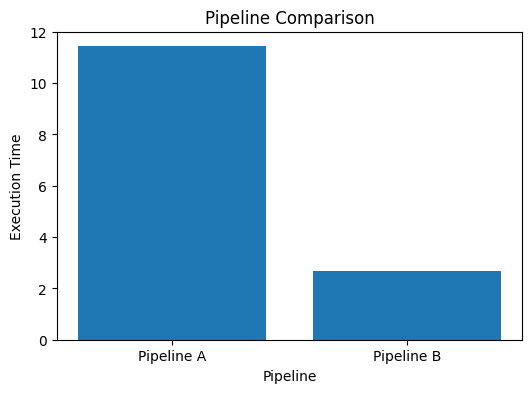

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    df["Pipeline"],
    df["Execution Time"]
)

plt.xlabel("Pipeline")

plt.ylabel("Execution Time")

plt.title("Pipeline Comparison")

plt.show()

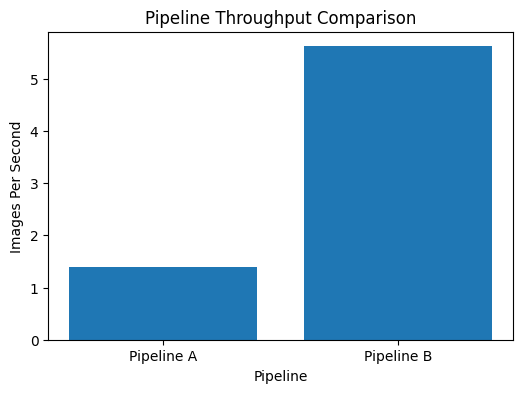

In [18]:
plt.figure(figsize=(6,4))

plt.bar(
    df["Pipeline"],
    df["Throughput"]
)

plt.xlabel("Pipeline")

plt.ylabel("Images Per Second")

plt.title("Pipeline Throughput Comparison")

plt.show()